In [1]:
import akshare as ak
import pandas as pd

# 用 akshare 下载美股数据（免费 + 稳定）
data = ak.stock_us_daily(symbol="AAPL", adjust="qfq")

# 处理日期索引
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')

# 只看最近 1 年
data = data['2025-04-28':'2026-04-28']

print(f"Shape: {data.shape}")
print(data.head())

Shape: (252, 5)
               open    high       low   close       volume
date                                                      
2025-04-28  208.960  210.46  206.4200  209.10   38742989.0
2025-04-29  207.653  211.20  207.3300  210.17   36827481.0
2025-04-30  208.260  212.54  205.6305  211.46   52286229.0
2025-05-01  208.040  213.52  207.8600  212.28   57365674.0
2025-05-02  205.050  205.95  201.1200  204.31  101010494.0


In [2]:
# 计算日收益率
data['returns'] = data['close'].pct_change()

# 累计收益（从 1 开始）
data['cumulative'] = (1 + data['returns']).cumprod()

# 年化指标（252 个交易日）
annual_return = data['returns'].mean() * 252
annual_vol = data['returns'].std() * (252 ** 0.5)
sharpe = (annual_return - 0.04) / annual_vol  # 假设无风险利率 4%

# 最大回撤
rolling_max = data['cumulative'].cummax()
drawdown = (data['cumulative'] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# 输出结果
print(f"=== AAPL 过去 1 年表现 ===")
print(f"年化收益: {annual_return:.2%}")
print(f"年化波动率: {annual_vol:.2%}")
print(f"夏普比率: {sharpe:.2f}")
print(f"最大回撤: {max_drawdown:.2%}")
print(f"\n累计收益: {data['cumulative'].iloc[-1]:.4f}")
print(f"（即 1 块钱投入变成 {data['cumulative'].iloc[-1]:.4f} 块）")

=== AAPL 过去 1 年表现 ===
年化收益: 28.68%
年化波动率: 23.50%
夏普比率: 1.05
最大回撤: -13.81%

累计收益: 1.2946
（即 1 块钱投入变成 1.2946 块）


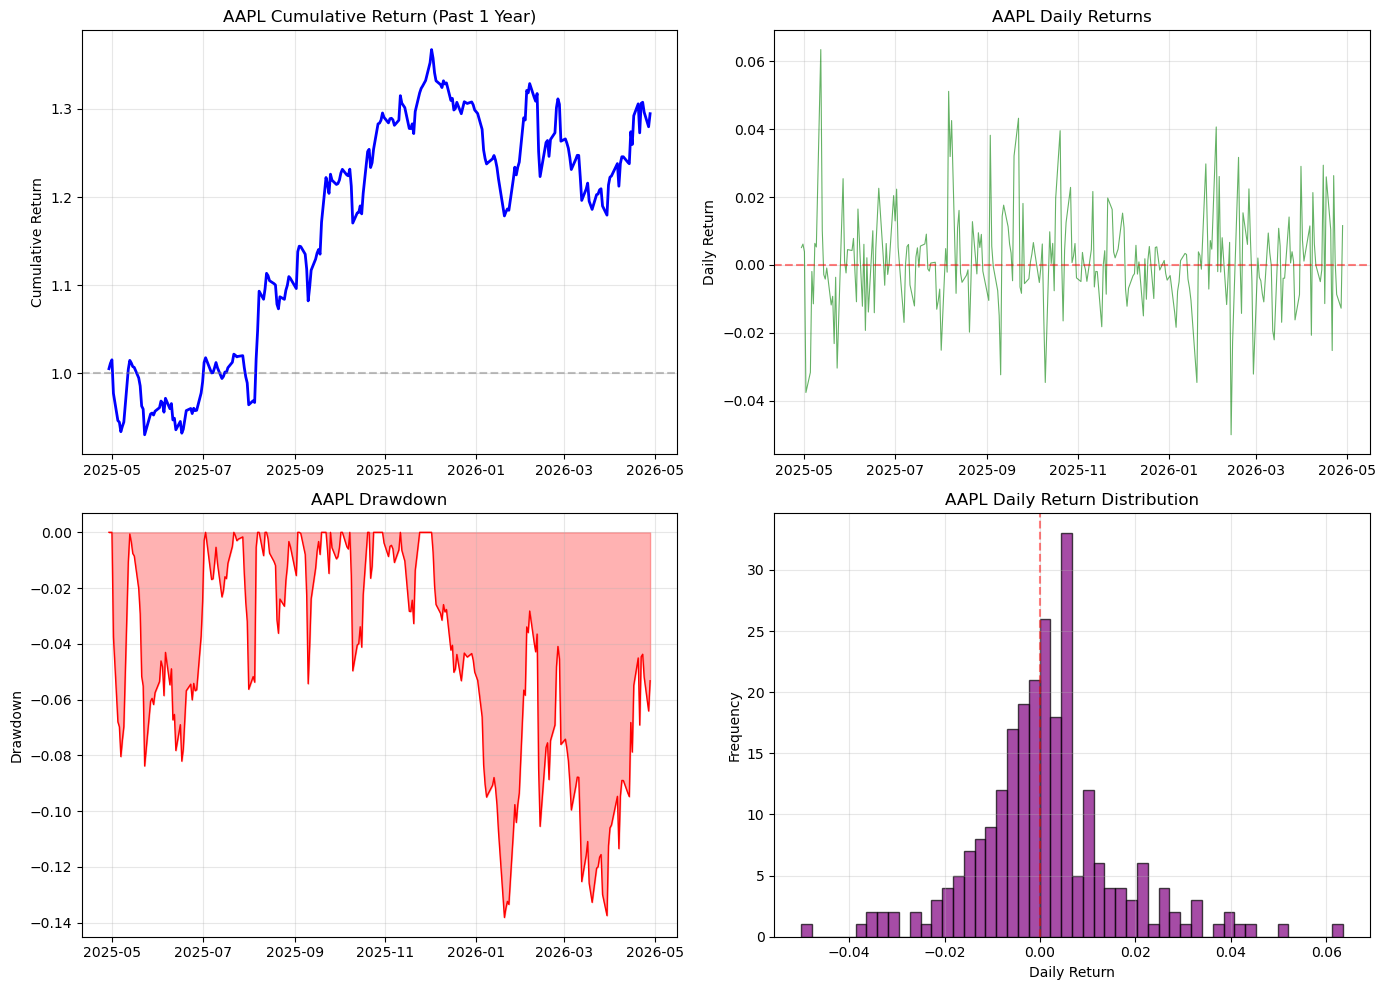

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 左上：累计收益
axes[0, 0].plot(data.index, data['cumulative'], color='blue', linewidth=2)
axes[0, 0].set_title('AAPL Cumulative Return (Past 1 Year)', fontsize=12)
axes[0, 0].set_ylabel('Cumulative Return')
axes[0, 0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].grid(True, alpha=0.3)

# 右上：日收益率
axes[0, 1].plot(data.index, data['returns'], color='green', alpha=0.6, linewidth=0.8)
axes[0, 1].set_title('AAPL Daily Returns', fontsize=12)
axes[0, 1].set_ylabel('Daily Return')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(True, alpha=0.3)

# 左下：回撤曲线
rolling_max = data['cumulative'].cummax()
drawdown = (data['cumulative'] - rolling_max) / rolling_max
axes[1, 0].fill_between(data.index, drawdown, 0, color='red', alpha=0.3)
axes[1, 0].plot(data.index, drawdown, color='red', linewidth=1)
axes[1, 0].set_title('AAPL Drawdown', fontsize=12)
axes[1, 0].set_ylabel('Drawdown')
axes[1, 0].grid(True, alpha=0.3)

# 右下：收益率分布
axes[1, 1].hist(data['returns'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('AAPL Daily Return Distribution', fontsize=12)
axes[1, 1].set_xlabel('Daily Return')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def calculate_metrics(data, name="Asset"):
    """计算单一资产的关键指标"""
    returns = data['close'].pct_change().dropna()
    cumulative = (1 + returns).cumprod()
    
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * (252 ** 0.5)
    sharpe = (annual_return - 0.04) / annual_vol
    
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    return {
        'name': name,
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'final_value': cumulative.iloc[-1]
    }


def print_metrics(metrics):
    """漂亮地打印指标"""
    print(f"=== {metrics['name']} ===")
    print(f"年化收益:   {metrics['annual_return']:>7.2%}")
    print(f"年化波动率: {metrics['annual_vol']:>7.2%}")
    print(f"夏普比率:   {metrics['sharpe']:>7.2f}")
    print(f"最大回撤:   {metrics['max_drawdown']:>7.2%}")
    print(f"$1 → ${metrics['final_value']:>7.4f}")
    print()


# 下载 SPY（S&P 500 ETF）作为基准
print("下载 SPY 中...")
spy_data = ak.stock_us_daily(symbol="SPY", adjust="qfq")
spy_data['date'] = pd.to_datetime(spy_data['date'])
spy_data = spy_data.set_index('date')
spy_data = spy_data['2025-04-28':'2026-04-28']

# 算两个资产的指标
aapl_metrics = calculate_metrics(data, "AAPL")
spy_metrics = calculate_metrics(spy_data, "SPY (S&P 500)")

# 对比打印
print_metrics(aapl_metrics)
print_metrics(spy_metrics)

# 谁赢了？
print("=" * 30)
if aapl_metrics['sharpe'] > spy_metrics['sharpe']:
    print(f"✅ AAPL 跑赢 SPY (夏普 {aapl_metrics['sharpe']:.2f} vs {spy_metrics['sharpe']:.2f})")
else:
    print(f"❌ AAPL 跑输 SPY (夏普 {aapl_metrics['sharpe']:.2f} vs {spy_metrics['sharpe']:.2f})")

下载 SPY 中...
=== AAPL ===
年化收益:    27.62%
年化波动率:  23.52%
夏普比率:      1.00
最大回撤:   -13.81%
$1 → $ 1.2798

=== SPY (S&P 500) ===
年化收益:    28.47%
年化波动率:  12.55%
夏普比率:      1.95
最大回撤:    -8.90%
$1 → $ 1.3159

❌ AAPL 跑输 SPY (夏普 1.00 vs 1.95)


In [6]:
from scipy import stats

returns = data['returns'].dropna()

# 描述性统计
print("=== AAPL 日收益率分布特征 ===")
print(f"均值:     {returns.mean():>8.4f}")
print(f"标准差:   {returns.std():>8.4f}")
print(f"偏度:     {returns.skew():>8.4f}  (0=对称, >0=右偏, <0=左偏)")
print(f"峰度:     {returns.kurtosis():>8.4f}  (0=正态, >0=厚尾)")
print()

# 正态性检验
stat, p_value = stats.jarque_bera(returns)
print(f"Jarque-Bera 检验:")
print(f"  统计量: {stat:.4f}")
print(f"  p-value: {p_value:.6f}")
if p_value < 0.05:
    print(f"  → 拒绝正态分布假设（数据不是正态的）")
else:
    print(f"  → 无法拒绝正态分布假设")

# 极端事件统计
print(f"\n=== 极端事件 ===")
print(f"最大单日涨幅: {returns.max():.2%}")
print(f"最大单日跌幅: {returns.min():.2%}")
print(f"涨 > 3% 的天数: {(returns > 0.03).sum()}")
print(f"跌 < -3% 的天数: {(returns < -0.03).sum()}")

=== AAPL 日收益率分布特征 ===
均值:       0.0011
标准差:     0.0148
偏度:       0.4716  (0=对称, >0=右偏, <0=左偏)
峰度:       2.3775  (0=正态, >0=厚尾)

Jarque-Bera 检验:
  统计量: 64.5609
  p-value: 0.000000
  → 拒绝正态分布假设（数据不是正态的）

=== 极端事件 ===
最大单日涨幅: 6.34%
最大单日跌幅: -5.00%
涨 > 3% 的天数: 10
跌 < -3% 的天数: 8
